In [1]:
# MODELS AND PREDICTION

In [2]:
# Train your First Baseline Model
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report

In [3]:
# Load Task 8 dataset
df1=pd.read_csv("cleaned_featured_churn_data.csv")
print(df1.head())

   SeniorCitizen  Partner  Dependents  tenure  PhoneService  PaperlessBilling  \
0              0        1           0       1             0                 1   
1              0        0           0      34             1                 0   
2              0        0           0       2             1                 1   
3              0        0           0      45             0                 0   
4              0        0           0       2             1                 1   

   MonthlyCharges  TotalCharges  Churn  TotalServicesUsed  ...  \
0           29.85         29.85      0                  1  ...   
1           56.95       1889.50      0                  2  ...   
2           53.85        108.15      1                  2  ...   
3           42.30       1840.75      0                  3  ...   
4           70.70        151.65      1                  0  ...   

   StreamingTV_Yes  StreamingMovies_No internet service  StreamingMovies_Yes  \
0                0                  

In [4]:
y=df1["Churn"]
x=df1.drop("Churn",axis=1)
print("X SHAPE:",x.shape)
print("Y SHAPE:",y.shape)

X SHAPE: (7043, 33)
Y SHAPE: (7043,)


In [5]:
# split the data into train and test 
x_train,x_test,y_train,y_test=train_test_split(
    x,y,test_size=0.20,random_state=42,stratify=y)
print("X Train data:", x_train.shape)
print("X Test data:", x_test.shape)
print("Y Train data:", y_train.shape)
print("Y Test data:", y_test.shape)

X Train data: (5634, 33)
X Test data: (1409, 33)
Y Train data: (5634,)
Y Test data: (1409,)


In [6]:
# Create Logistic Regression model
model=LogisticRegression(max_iter=10000)
#  Train the model
model.fit(x_train,y_train)
print("model trained sucessfully")

model trained sucessfully


In [7]:
# Make predictions
y_pred=model.predict(x_test)
print(y_pred)

[0 1 0 ... 0 0 0]


In [8]:
# Show predictions for 5 customers
print("Actual:",y_test.iloc[:5])
print("Predict:",y_pred[:5])

Actual: 437     0
2280    0
2235    0
4460    0
3761    0
Name: Churn, dtype: int64
Predict: [0 1 0 0 0]


In [9]:
# checking accuracy
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy",round(accuracy*100,2))

Accuracy 80.55


In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix,classification_report

[[933 102]
 [172 202]]


Text(50.83333333333333, 0.5, 'ACTUAL')

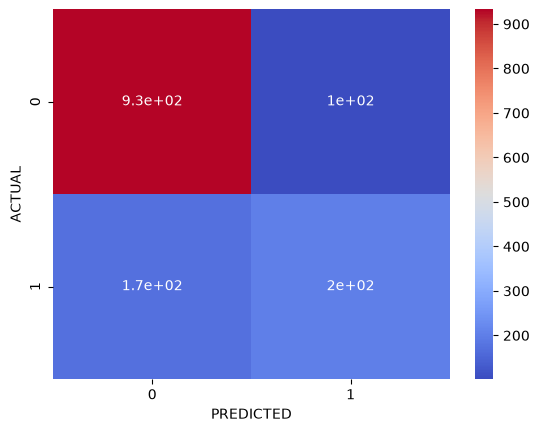

In [11]:
# Generate confusion matrix for task 9 model
cf=confusion_matrix(y_test,y_pred)
print(cf)
sns.heatmap(cf,annot=True,cmap="coolwarm")
plt.xlabel("PREDICTED")
plt.ylabel("ACTUAL")


In [12]:
# calculate precision,recall,f1 score 
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.84      0.90      0.87      1035
           1       0.66      0.54      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.80      0.81      0.80      1409



In [13]:
pip install imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [14]:
from imblearn.over_sampling import SMOTE

In [15]:
# Before smote
print("Before smote")
print(y_train.value_counts())

Before smote
Churn
0    4139
1    1495
Name: count, dtype: int64


In [16]:
# Applying smote
smote=SMOTE(random_state=42)

In [17]:
# # Applying smote only to training data
x_train_smote,y_train_smote=smote.fit_resample(x_train,y_train)

In [18]:
print("After smote")
print(y_train_smote.value_counts())

After smote
Churn
0    4139
1    4139
Name: count, dtype: int64


In [19]:
# Retrain your LogisticRegression model on the balanced training data
model_smote=LogisticRegression(max_iter=10000)
model_smote.fit(x_train_smote,y_train_smote)
print("Model Re-trained successfully")

Model Re-trained successfully


In [20]:
# Make predictions 
y_pred_smote=model_smote.predict(x_test)
print(y_pred_smote)

[0 1 0 ... 1 0 0]


In [21]:
# Test accuracy 
accuracy=accuracy_score(y_test,y_pred_smote)
print("Accuracy",round(accuracy*100,2))

Accuracy 77.64


[[851 184]
 [131 243]]


Text(50.83333333333333, 0.5, 'ACTUAL')

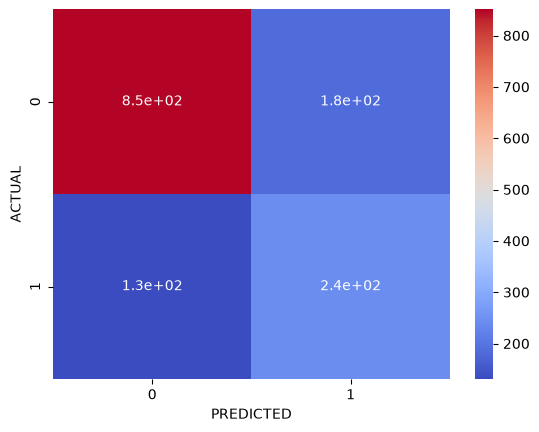

In [22]:
# confusion_matrix
cf_smote=confusion_matrix(y_test,y_pred_smote)
print(cf_smote)
sns.heatmap(cf_smote,annot=True,cmap="coolwarm")
plt.xlabel("PREDICTED")
plt.ylabel("ACTUAL")

In [23]:
# calculate precision,recall,f1 score
print(classification_report(y_test,y_pred_smote))

              precision    recall  f1-score   support

           0       0.87      0.82      0.84      1035
           1       0.57      0.65      0.61       374

    accuracy                           0.78      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.78      0.78      1409



In [24]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

In [26]:
# create LogisticRegression model
lr_model=LogisticRegression(max_iter=10000)

# used gridsearchcv 
lr_grid = GridSearchCV(lr_model,
    {"C": [0.1, 1, 10]},
    scoring="f1",
    cv=3)
lr_grid.fit(x_train_smote,y_train_smote)
print("LogisticRegression model trained successfully")

LogisticRegression model trained successfully


In [27]:
# Make predictions for LogisticRegression model
lr_pred=lr_grid.predict(x_test)
print(lr_pred)

[0 1 0 ... 1 0 0]


In [28]:
# confusion_matrix of LogisticRegression model
cf_lr_model=confusion_matrix(y_test,lr_pred)
print("confusion_matrix",cf_lr_model)

# calculate precision,recall,f1 score  of LogisticRegression model
print("classification_report",classification_report(y_test,lr_pred))
print("Best Parameters", lr_grid.best_params_)

confusion_matrix [[843 192]
 [123 251]]
classification_report               precision    recall  f1-score   support

           0       0.87      0.81      0.84      1035
           1       0.57      0.67      0.61       374

    accuracy                           0.78      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.78      0.78      1409

Best Parameters {'C': 0.1}


In [29]:
# create RandomForestClassifier model
rf_model=RandomForestClassifier(n_estimators=200,random_state=42)

# used gridsearchcv 
rf_grid=GridSearchCV(rf_model,{"n_estimators":[100,200]},scoring="f1",
    cv=3)
rf_grid.fit(x_train_smote,y_train_smote)
print("RandomForestClassifier model trained successfully")

RandomForestClassifier model trained successfully


In [30]:
# Make predictions for RandomForestClassifier model
rf_pred=rf_grid.predict(x_test)
print(rf_pred)

[0 1 0 ... 0 0 0]


In [31]:
# confusion_matrix of RandomForestClassifier model
cf_rf_model=confusion_matrix(y_test,rf_pred)
print("confusion_matrix",cf_rf_model)

# calculate precision,recall,f1 score  of RandomForestClassifier model
print("classification_report",classification_report(y_test,rf_pred))
print("Best Parameters", rf_grid.best_params_)

confusion_matrix [[869 166]
 [152 222]]
classification_report               precision    recall  f1-score   support

           0       0.85      0.84      0.85      1035
           1       0.57      0.59      0.58       374

    accuracy                           0.77      1409
   macro avg       0.71      0.72      0.71      1409
weighted avg       0.78      0.77      0.78      1409

Best Parameters {'n_estimators': 200}


In [32]:
# create XGBClassifier
xgb_model=XGBClassifier(random_state=42)

# used gridsearchcv 
xgb_grid=GridSearchCV(xgb_model,{"n_estimators":[100,200]},scoring="f1",
    cv=3)
xgb_grid.fit(x_train_smote,y_train_smote)
print("XGBClassifier model trained successfully")

XGBClassifier model trained successfully


In [33]:
# Make predictions for XGBClassifier model
xgb_pred=xgb_grid.predict(x_test)
print(xgb_pred)

[0 1 0 ... 0 1 0]


In [34]:
# confusion_matrix of XGBClassifier model
cf_xgb_model=confusion_matrix(y_test,xgb_pred)
print("confusion_matrix",cf_xgb_model)

# calculate precision,recall,f1 score  of XGBClassifier model
print("classification_report",classification_report(y_test,xgb_pred))
print("Best Parameters", xgb_grid.best_params_)

confusion_matrix [[869 166]
 [153 221]]
classification_report               precision    recall  f1-score   support

           0       0.85      0.84      0.84      1035
           1       0.57      0.59      0.58       374

    accuracy                           0.77      1409
   macro avg       0.71      0.72      0.71      1409
weighted avg       0.78      0.77      0.77      1409

Best Parameters {'n_estimators': 100}


In [35]:
from sklearn.metrics import precision_score,recall_score,f1_score,accuracy_score

In [36]:
# comparison_table of 3 models for churn
comparison_table=pd.DataFrame({
    "Model":["LogisticRegression","RandomForestClassifier","XGBClassifier"],
    "Precision":[precision_score(y_test,lr_pred),precision_score(y_test,rf_pred),precision_score(y_test,xgb_pred)],
    "Recall":[recall_score(y_test,lr_pred),recall_score(y_test,rf_pred),recall_score(y_test,xgb_pred)],
    "F1":[f1_score(y_test,lr_pred),f1_score(y_test,rf_pred),f1_score(y_test,xgb_pred)],
    "Accuracy":[accuracy_score(y_test,lr_pred),accuracy_score(y_test,rf_pred),accuracy_score(y_test,xgb_pred)]
})
comparison_table[["Precision", "Recall", "F1", "Accuracy"]]=comparison_table[["Precision", "Recall", "F1", "Accuracy"]] * 100
print(comparison_table)

                    Model  Precision     Recall         F1   Accuracy
0      LogisticRegression  56.659142  67.112299  61.444308  77.643719
1  RandomForestClassifier  57.216495  59.358289  58.267717  77.430802
2           XGBClassifier  57.105943  59.090909  58.081472  77.359830


In [37]:
pip install mlflow

Note: you may need to restart the kernel to use updated packages.


In [38]:
import mlflow

In [39]:
# create experiment on Customer Churn Prediction1
mlflow.set_experiment("Customer Churn Prediction1")

<Experiment: artifact_location='file:C:/Users/Surya/mlruns/2', creation_time=1788348789650, effective_trace_archival_retention=None, experiment_id='2', last_update_time=1788348789650, lifecycle_stage='active', name='Customer Churn Prediction1', tags={}, trace_location=None, workspace='default'>

In [40]:
# Logistic Regression log
with mlflow.start_run(run_name="LogisticRegression"):
    mlflow.log_param("C",lr_grid.best_params_["C"])
    mlflow.log_metric("Precision",precision_score(y_test,lr_pred))
    mlflow.log_metric("Recall",recall_score(y_test,lr_pred))
    mlflow.log_metric("F1",f1_score(y_test,lr_pred))
    mlflow.log_metric("Accuracy",accuracy_score(y_test,lr_pred))
print("Logistic Regression logged Successfully")

2026/09/17 19:02:53 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably not on your PATH), so Git SHA is not available. Error: Failed to initialize: Bad git executable.
The git executable must be specified in one of the following ways:
    - be included in your $PATH
    - be set via $GIT_PYTHON_GIT_EXECUTABLE
    - explicitly set via git.refresh(<full-path-to-git-executable>)

All git commands will error until this is rectified.

This initial message can be silenced or aggravated in the future by setting the
$GIT_PYTHON_REFRESH environment variable. Use one of the following values:
    - quiet|q|silence|s|silent|none|n|0: for no message or exception
    - warn|w|warning|log|l|1: for a warning message (logging level CRITICAL, displayed by default)
    - error|e|exception|raise|r|2: for a raised exception

Example:
    export GIT_PYTHON_REFRESH=quiet

2026/09/17 19:02:53 WARNING mlflow.utils.git_utils: Failed to import Git (the Git executable is probably

Logistic Regression logged Successfully


In [41]:
# RandomForestClassifier log
with mlflow.start_run(run_name="RandomForestClassifier"):
    mlflow.log_param("n_estimators",rf_grid.best_params_["n_estimators"])
    mlflow.log_metric("Precision",precision_score(y_test,rf_pred))
    mlflow.log_metric("Recall",recall_score(y_test,rf_pred))
    mlflow.log_metric("F1",f1_score(y_test,rf_pred))
    mlflow.log_metric("Accuracy",accuracy_score(y_test,rf_pred))
print("RandomForestClassifier logged Successfully")

RandomForestClassifier logged Successfully


In [42]:
# XGBClassifier log
with mlflow.start_run(run_name="XGBClassifier"):
    mlflow.log_param("n_estimators",xgb_grid.best_params_["n_estimators"])
    mlflow.log_metric("Precision",precision_score(y_test,xgb_pred))
    mlflow.log_metric("Recall",recall_score(y_test,xgb_pred))
    mlflow.log_metric("F1",f1_score(y_test,xgb_pred))
    mlflow.log_metric("Accuracy",accuracy_score(y_test,xgb_pred))
print("XGBClassifier logged Successfully")


XGBClassifier logged Successfully


In [43]:
# best_model -logisticRegression
best_model_lr=lr_grid.best_estimator_
print(best_model_lr)

LogisticRegression(C=0.1, max_iter=10000)


In [44]:
# import sql dataset for churn_probability per customer
import pyodbc
import pandas as pd

conn = pyodbc.connect(
    "DRIVER={ODBC Driver 18 for SQL Server};"
    "SERVER=localhost;"
    "DATABASE=ChurnDB;"
    "Trusted_Connection=yes;"
    "TrustServerCertificate=yes;"
)

print("SQL Server connected successfully")

SQL Server connected successfully


In [45]:
query = "SELECT * FROM dbo.vw_ChurnData"

df= pd.read_sql(query, conn)

print(df.shape)
print(df.head())

C:\Users\Surya\AppData\Local\Temp\ipykernel_37008\2089580658.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df= pd.read_sql(query, conn)


(7043, 21)
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Co

In [46]:
# churn predictions
predictions = df[
    ["customerID","tenure","MonthlyCharges","TotalCharges","InternetService","Contract", "Churn"]].copy()
predictions["TotalServicesUsed"] = df1["TotalServicesUsed"].values
print(predictions.shape)
print(predictions.head())

(7043, 8)
   customerID  tenure  MonthlyCharges  TotalCharges InternetService  \
0  7590-VHVEG       1           29.85         29.85             DSL   
1  5575-GNVDE      34           56.95       1889.50             DSL   
2  3668-QPYBK       2           53.85        108.15             DSL   
3  7795-CFOCW      45           42.30       1840.75             DSL   
4  9237-HQITU       2           70.70        151.65     Fiber optic   

         Contract Churn  TotalServicesUsed  
0  Month-to-month    No                  1  
1        One year    No                  2  
2  Month-to-month   Yes                  2  
3        One year    No                  3  
4  Month-to-month   Yes                  0  


In [47]:
# churn_probability
churn_probability=best_model_lr.predict_proba(x)[:,1]
print(churn_probability)
predictions["ChurnProbability"] =churn_probability

# PredictedChurn
predictions["PredictedChurn"] = (predictions["ChurnProbability"] >= 0.50).map({True: "Yes",False: "No"})
print(predictions["PredictedChurn"].value_counts())

[0.7057049  0.06187823 0.32337223 ... 0.40191524 0.66955235 0.17434104]
PredictedChurn
No     4825
Yes    2218
Name: count, dtype: int64


In [48]:
# identify RiskLevel  
predictions["RiskLevel"] = (predictions["ChurnProbability"] >= 0.70).map({True:"High Risk",False:"Normal Risk"})
print(predictions["RiskLevel"].value_counts())

# checking dataset
print(predictions.columns)
print(predictions.shape)
print(predictions.head())

RiskLevel
Normal Risk    5888
High Risk      1155
Name: count, dtype: int64
Index(['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges',
       'InternetService', 'Contract', 'Churn', 'TotalServicesUsed',
       'ChurnProbability', 'PredictedChurn', 'RiskLevel'],
      dtype='object')
(7043, 11)
   customerID  tenure  MonthlyCharges  TotalCharges InternetService  \
0  7590-VHVEG       1           29.85         29.85             DSL   
1  5575-GNVDE      34           56.95       1889.50             DSL   
2  3668-QPYBK       2           53.85        108.15             DSL   
3  7795-CFOCW      45           42.30       1840.75             DSL   
4  9237-HQITU       2           70.70        151.65     Fiber optic   

         Contract Churn  TotalServicesUsed  ChurnProbability PredictedChurn  \
0  Month-to-month    No                  1          0.705705            Yes   
1        One year    No                  2          0.061878             No   
2  Month-to-month   Yes            

In [49]:
# retention_strategy
def retention_strategy(df):
    if df["RiskLevel"] == "High Risk":
        if df["Contract"] == "Month-to-month":
            return "Offer contract upgrade discount"
        elif df["Contract"] == "One year":
            return "Offer loyalty benefit"
        elif df["Contract"] == "Two year":
            return "Provide proactive customer support"

    return "Continue regular engagement"


predictions["RetentionStrategy"] = predictions.apply(retention_strategy,axis=1)
print(predictions["RetentionStrategy"].head())

0    Offer contract upgrade discount
1        Continue regular engagement
2        Continue regular engagement
3        Continue regular engagement
4    Offer contract upgrade discount
Name: RetentionStrategy, dtype: object


In [50]:
print(predictions.columns.tolist())
print(predictions[["customerID", "Contract", "RiskLevel", "RetentionStrategy"]].head(10))

['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges', 'InternetService', 'Contract', 'Churn', 'TotalServicesUsed', 'ChurnProbability', 'PredictedChurn', 'RiskLevel', 'RetentionStrategy']
   customerID        Contract    RiskLevel                RetentionStrategy
0  7590-VHVEG  Month-to-month    High Risk  Offer contract upgrade discount
1  5575-GNVDE        One year  Normal Risk      Continue regular engagement
2  3668-QPYBK  Month-to-month  Normal Risk      Continue regular engagement
3  7795-CFOCW        One year  Normal Risk      Continue regular engagement
4  9237-HQITU  Month-to-month    High Risk  Offer contract upgrade discount
5  9305-CDSKC  Month-to-month    High Risk  Offer contract upgrade discount
6  1452-KIOVK  Month-to-month  Normal Risk      Continue regular engagement
7  6713-OKOMC  Month-to-month  Normal Risk      Continue regular engagement
8  7892-POOKP  Month-to-month  Normal Risk      Continue regular engagement
9  6388-TABGU        One year  Normal Risk      

In [82]:
print(
    predictions.groupby(
        ["RiskLevel", "Contract"]
    ).size()
)

RiskLevel    Contract      
High Risk    Month-to-month    1155
Normal Risk  Month-to-month    2720
             One year          1473
             Two year          1695
dtype: int64


In [51]:
# save ChurnPredictions
predictions.to_csv("ChurnPredictions.csv", index=False)
predictions.to_csv(r"C:\Users\Surya\OneDrive\Desktop\CUSTOMER CHURN PROJECT\ChurnPredictions.csv",index=False)

print("Churn predictions updated successfully!")

Churn predictions updated successfully!


In [52]:
# selected XGBoost for feature importance
best_xgb = xgb_grid.best_estimator_

In [53]:
# feature importance
f_list=list(x.columns)
feature_importance=pd.Series(best_xgb.feature_importances_.ravel(),index=f_list).sort_values(ascending=False)
print(feature_importance.head(10))

Contract_Two year                 0.341411
Contract_One year                 0.156271
InternetService_No                0.142786
MultipleLines_No phone service    0.052691
Customer_segment_Loyal            0.044182
OnlineSecurity_Yes                0.025901
Dependents                        0.023591
PhoneService                      0.021080
TechSupport_Yes                   0.020941
PaymentMethod_Mailed check        0.020336
dtype: float32


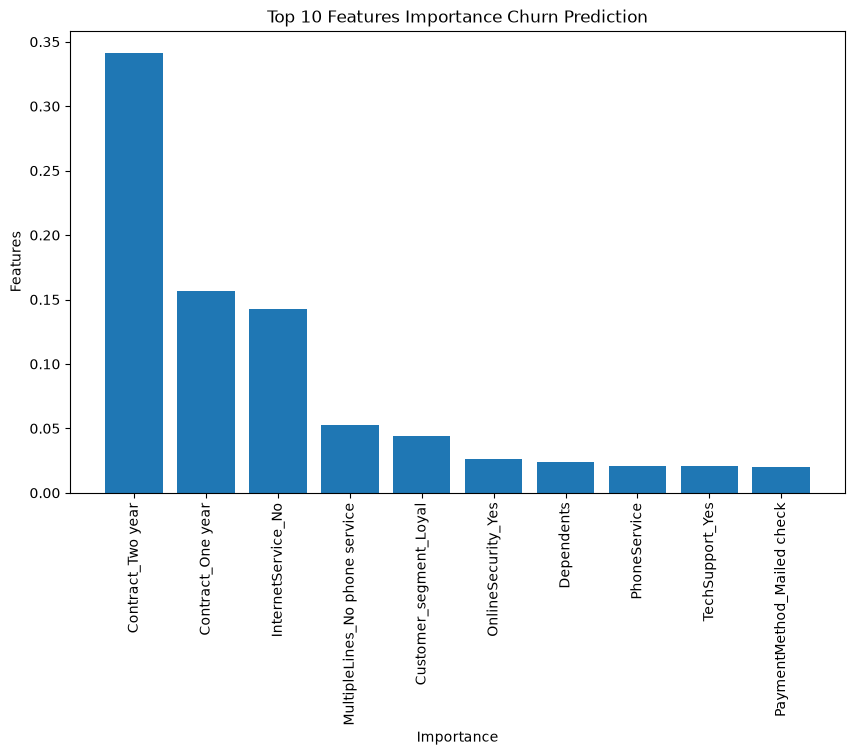

In [54]:
# Feature Importance Chart

feature_chart=feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.bar(feature_chart.index,feature_chart.values)
plt.xlabel("Importance")
plt.ylabel("Features")
plt.xticks(rotation=90)
plt.title("Top 10 Features Importance Churn Prediction")
plt.show()

In [55]:
pip install lime

Note: you may need to restart the kernel to use updated packages.


In [56]:
from lime.lime_tabular import LimeTabularExplainer
import numpy as np

In [57]:
explainer=LimeTabularExplainer(x_train_smote.values,feature_names=x_train_smote.columns,class_names=["No churn","churn"],
                               mode="classification",random_state=42)

C:\Users\Surya\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


[('MonthlyCharges > 91.09', 0.35659119192101507), ('TechSupport_Yes > 0.00', -0.17672342149178677), ('OnlineSecurity_Yes <= 0.00', 0.16916621119127545), ('Contract_Two year <= 0.00', 0.16043091010977054), ('OnlineBackup_Yes <= 0.00', 0.15250504568387357), ('DeviceProtection_Yes <= 0.00', 0.12548450665699898), ('0.00 < StreamingMovies_Yes <= 1.00', -0.12300058535252649), ('0.00 < InternetService_Fiber optic <= 1.00', -0.11380270879579658), ('5.00 < tenure <= 22.00', 0.11047883303826056), ('0.00 < StreamingTV_Yes <= 1.00', -0.10510239503066875)]


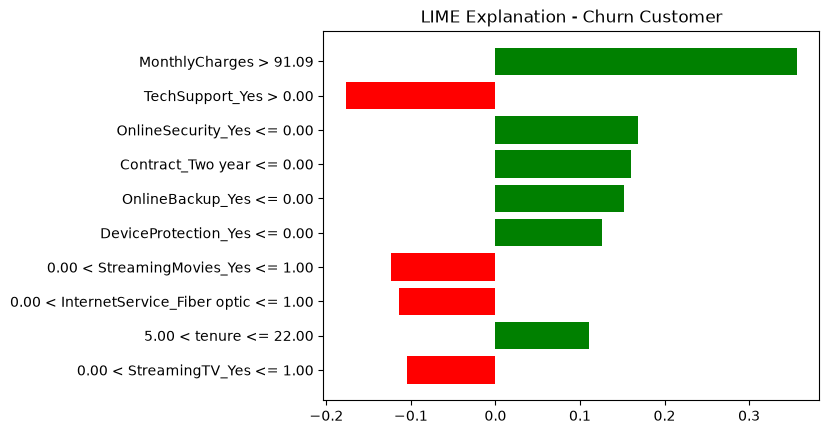

Prediction: Churn
No Churn Probability: 0.3050374390575237
Churn Probability: 0.6949625609424763


In [58]:
# LIME Explanation - Churn Customer
churn = x_test.iloc[1].values
exp_churn=explainer.explain_instance(churn,best_model_lr.predict_proba,num_features=10)

print(exp_churn.as_list())
exp_churn.as_pyplot_figure()
plt.title("LIME Explanation - Churn Customer")
plt.show()

# prediction and probability
prediction = best_model_lr.predict(x_test.iloc[[1]])[0]
probability = best_model_lr.predict_proba(x_test.iloc[[1]])[0]

print("Prediction:", "Churn" if prediction == 1 else "No Churn")
print("No Churn Probability:", probability[0])
print("Churn Probability:", probability[1])
                               

C:\Users\Surya\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


[('MonthlyCharges > 91.09', 0.3442437889930881), ('TotalServicesUsed > 3.00', 0.24052319016260473), ('tenure > 49.00', -0.21797912646214615), ('TotalCharges > 3398.12', 0.1857964254004631), ('TechSupport_Yes > 0.00', -0.18173502575331613), ('Contract_Two year > 0.00', -0.16891480386158025), ('OnlineSecurity_Yes > 0.00', -0.1669078836405247), ('0.00 < OnlineBackup_Yes <= 1.00', -0.14925410780870224), ('0.00 < StreamingMovies_Yes <= 1.00', -0.1328872966595289), ('0.00 < StreamingTV_Yes <= 1.00', -0.12516478492860883)]


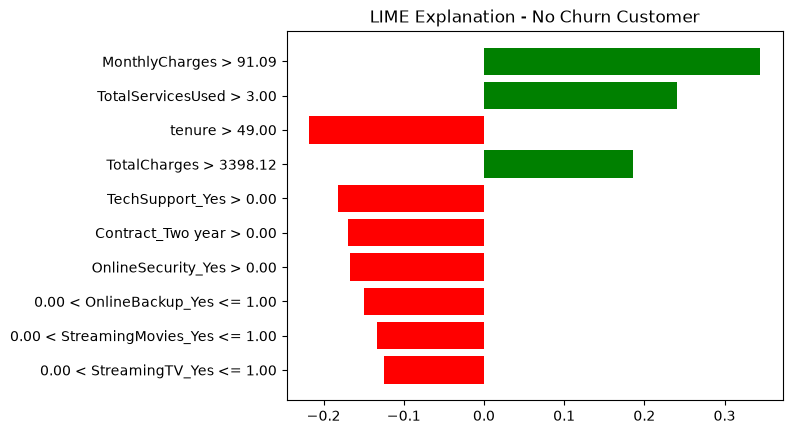

Prediction: No Churn
No Churn Probability: 0.9725120039138446
Churn Probability: 0.027487996086155368


In [59]:
predicted_churn = best_model_lr.predict(x_test)

no_churn_index = np.where(predicted_churn == 0)[0][0]

exp_no_churn = explainer.explain_instance(x_test.iloc[no_churn_index].values,best_model_lr.predict_proba,num_features=10)

print(exp_no_churn.as_list())
exp_no_churn.as_pyplot_figure()
plt.title("LIME Explanation - No Churn Customer")
plt.show()


# prediction and probability
prediction = best_model_lr.predict(x_test.iloc[[no_churn_index]])[0]

print("Prediction:", "Churn" if prediction == 1 else "No Churn")
probability = best_model_lr.predict_proba(
    x_test.iloc[[no_churn_index]]
)[0]

print("No Churn Probability:", probability[0])
print("Churn Probability:", probability[1])

In [60]:
# new_customer
customer = {
    "gender": "Female",
    "SeniorCitizen": 0,
    "Partner": "Yes",
    "Dependents": "No",
    "tenure": 18,
    "PhoneService": "Yes",
    "MultipleLines": "No",
    "InternetService": "Fiber optic",
    "OnlineSecurity": "Yes",
    "OnlineBackup": "No",
    "DeviceProtection": "Yes",
    "TechSupport": "No",
    "StreamingTV": "No",
    "StreamingMovies": "No",
    "Contract": "One year",
    "PaperlessBilling": "Yes",
    "PaymentMethod":"Mailed check ",
    "MonthlyCharges": 95.50,
    "TotalCharges": 1719
}

In [61]:
# validate_customer
def validate_customer(customer):

    required_fields = [
        "gender",
        "SeniorCitizen",
        "Partner",
        "Dependents",
        "tenure",
        "PhoneService",
        "MultipleLines",
        "InternetService",
        "OnlineSecurity",
        "OnlineBackup",
        "DeviceProtection",
        "TechSupport",
        "StreamingTV",
        "StreamingMovies",
        "Contract",
        "PaperlessBilling",
        "PaymentMethod",
        "MonthlyCharges",
        "TotalCharges"
    ]
    
    for field in required_fields:
        if field not in customer:
            raise ValueError(f"Missing field: {field}")

# Check tenure
    if not isinstance(customer["tenure"], (int, float)):
        raise TypeError("Tenure must be a number.")

    if customer["tenure"] < 0:
        raise ValueError("Tenure cannot be negative.")

# Check MonthlyCharges
    if not isinstance(customer["MonthlyCharges"], (int, float)):
        raise TypeError("MonthlyCharges must be a number.")
        
    if customer["MonthlyCharges"] < 0:
        raise ValueError("MonthlyCharges cannot be negative.")

# Check TotalCharges
    if not isinstance(customer["TotalCharges"], (int, float)):
        raise TypeError("TotalCharges must be a number.")
        
    if customer["TotalCharges"] < 0:
        raise ValueError("TotalCharges cannot be negative.")

print("Customer data is valid.")

Customer data is valid.


In [62]:
# validate_customer
def predict_new_customer(customer):

    try:
        validate_customer(customer)
        print("Customer validation successful.")

    except Exception as e: 
        print("Prediction failed:", e)

predict_new_customer(customer)

customer_df = pd.DataFrame([customer])

Customer validation successful.


In [63]:
# create TotalServicesUsed
service_columns=[
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]
customer_df['TotalServicesUsed'] = customer_df[service_columns].apply(lambda row: (row == 'Yes').sum(),axis=1)

print(customer_df[['TotalServicesUsed']])    

   TotalServicesUsed
0                  2


In [64]:
# Convert Yes/No columns into 1/0.
binary_columns = [
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling",
]

for col in binary_columns:
    customer_df[col] = customer_df[col].map({"Yes": 1, "No": 0})

print(customer_df[binary_columns].head())

   Partner  Dependents  PhoneService  PaperlessBilling
0        1           0             1                 1


In [65]:
# One-Hot Encoding for the cleaned dataset
categorical_columns = [
    'gender',
    'MultipleLines',
    'InternetService',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies',
    'Contract',
    'PaymentMethod',
]
customer_df=pd.get_dummies(customer_df,columns=categorical_columns,drop_first=True,dtype=int)
print(customer_df.dtypes)
print(customer_df.head())

SeniorCitizen          int64
Partner                int64
Dependents             int64
tenure                 int64
PhoneService           int64
PaperlessBilling       int64
MonthlyCharges       float64
TotalCharges           int64
TotalServicesUsed      int64
dtype: object
   SeniorCitizen  Partner  Dependents  tenure  PhoneService  PaperlessBilling  \
0              0        1           0      18             1                 1   

   MonthlyCharges  TotalCharges  TotalServicesUsed  
0            95.5          1719                  2  


In [66]:
# Match model columns
customer_df = customer_df.reindex(columns=x.columns, fill_value=0)

# churn probability
churn_probability = best_model_lr.predict_proba(customer_df)[0][1]

# Show result
print("Churn Probability:", round(churn_probability * 100, 2), "%")

if churn_probability >= 0.50:
    print("Prediction: Churn")
else:
    print("Prediction: No Churn")


Churn Probability: 99.8 %
Prediction: Churn


In [67]:
# 1 bad Input : Missing field
bad_input1 = customer.copy()

del bad_input1["tenure"]

probability = predict_new_customer(bad_input1)

Prediction failed: Missing field: tenure


In [68]:
# 2 bad Input: Wrong data type

bad_input2 = customer.copy()

bad_input2["tenure"] = "ten"

probability = predict_new_customer(bad_input2)

Prediction failed: Tenure must be a number.


In [69]:
# 3  bad Input: Negative tenure
bad_input3 = customer.copy()

bad_input3["tenure"] = -5

probability = predict_new_customer(bad_input3)

Prediction failed: Tenure cannot be negative.


In [70]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import joblib

In [71]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model",lr_grid)
])

In [72]:
# 2. Train pipeline
pipeline.fit(x_train_smote, y_train_smote)
print("Pipeline trained successfully.")

Pipeline trained successfully.


In [73]:
# 3. Make predictions
pipeline_pred = pipeline.predict(x_test)
print(pipeline_pred)

[0 1 0 ... 1 0 0]


In [74]:
# confusion_matrix of pipeline
cf_pipeline=confusion_matrix(y_test,pipeline_pred)
print("confusion_matrix",cf_pipeline)

# calculate precision,recall,f1 score  of LogisticRegression model
print("Pipeline Results")
print("classification_report",classification_report(y_test,pipeline_pred))

confusion_matrix [[847 188]
 [130 244]]
Pipeline Results
classification_report               precision    recall  f1-score   support

           0       0.87      0.82      0.84      1035
           1       0.56      0.65      0.61       374

    accuracy                           0.77      1409
   macro avg       0.72      0.74      0.72      1409
weighted avg       0.79      0.77      0.78      1409



In [75]:
# 5. Get churn probability

probability = pipeline.predict_proba(x_test.iloc[[0]])[0][1]

print("Churn Probability:",round(probability * 100, 2))

if probability >= 0.50:
    print("Prediction: Churn")
else:
    print("Prediction: No Churn")

Churn Probability: 2.03
Prediction: No Churn


In [76]:
joblib.dump(pipeline,"churn_pipeline.pkl")

print("Pipeline saved successfully.")

Pipeline saved successfully.


In [77]:
# Load the saved pipeline
import joblib

load_pipeline = joblib.load("churn_pipeline.pkl")

print("Pipeline loaded successfully.")

Pipeline loaded successfully.


In [78]:
# Churn Probability
customer = x_test.iloc[[0]]

probability = load_pipeline.predict_proba(customer)[0][1]

print("Churn Probability:", round(probability * 100, 2))

Churn Probability: 2.03


In [79]:
# make prediction
prediction = load_pipeline.predict(customer)[0]

if prediction == 1:
    print("Prediction: Churn")
else:
    print("Prediction: No Churn")

Prediction: No Churn


In [80]:
!pip install streamlit

In [81]:
import streamlit

print(streamlit.__version__)

1.58.0
